What does the distribution of point-level pressure look like across the dataset?

In [10]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[1]
DATA_PROCESSED = ROOT / "data_processed"
OUTPUTS = ROOT / "outputs"

in_path = DATA_PROCESSED / "07_analysis_dataset.parquet"
df = pd.read_parquet(in_path)

In [11]:
df.shape
df.columns
df["pressure_swing"].isna().sum()
df["pressure_swing"].describe()

count    39264.000000
mean         0.015723
std          0.020128
min          0.000000
25%          0.001667
50%          0.008737
75%          0.022205
max          0.282146
Name: pressure_swing, dtype: float64

Sample histogram

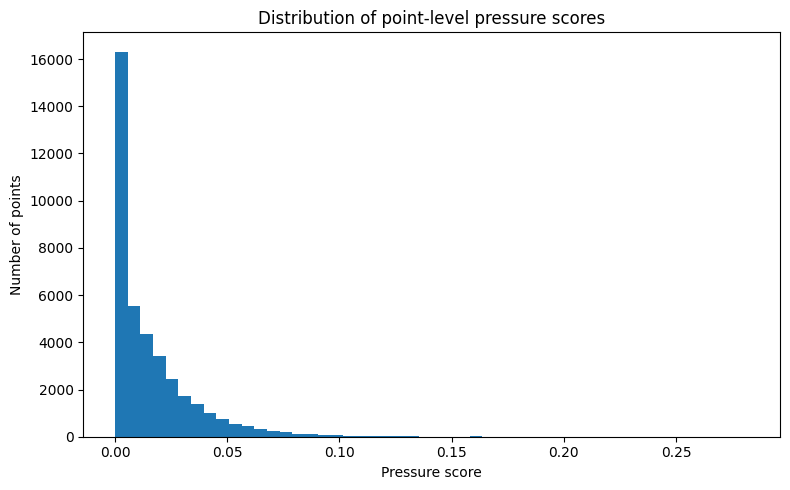

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["pressure_swing"], bins=50)
plt.xlabel("Pressure score")
plt.ylabel("Number of points")
plt.title("Distribution of point-level pressure scores")
plt.tight_layout()
plt.savefig(OUTPUTS / "pressure_distribution.png", dpi=300)
plt.show()

Key percentiles

In [7]:
percentiles = df["pressure_swing"].quantile([0.50, 0.75, 0.90, 0.95, 0.99])
print(percentiles)

0.50    0.008737
0.75    0.022205
0.90    0.040417
0.95    0.054925
0.99    0.089178
Name: pressure_swing, dtype: float64


In [ ]:
pressure_summary = pd.DataFrame({
    "statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "value": [
        df["pressure_swing"].count(),
        df["pressure_swing"].mean(),
        df["pressure_swing"].std(),
        df["pressure_swing"].min(),
        df["pressure_swing"].quantile(0.25),
        df["pressure_swing"].quantile(0.50),
        df["pressure_swing"].quantile(0.75),
        df["pressure_swing"].max(),
    ]
})

pressure_percentiles = pd.DataFrame({
    "percentile": ["90%", "95%", "99%"],
    "value": [
        df["pressure_swing"].quantile(0.90),
        df["pressure_swing"].quantile(0.95),
        df["pressure_swing"].quantile(0.99),
    ]
})

pressure_summary.to_csv(OUTPUTS / "tables/pressure_summary.csv", index=False)
pressure_percentiles.to_csv(OUTPUTS / "tables/pressure_percentiles.csv", index=False)


pressure_percentiles

,percentile,value
0,90%,0.040417
1,95%,0.054925
2,99%,0.089178


In [17]:
pressure_summary

,statistic,value
0,count,39264.000000
1,mean,0.015723
2,std,0.020128
3,min,0.000000
4,25%,0.001667
5,50%,0.008737
6,75%,0.022205
7,max,0.282146


Histogram zoomed-in

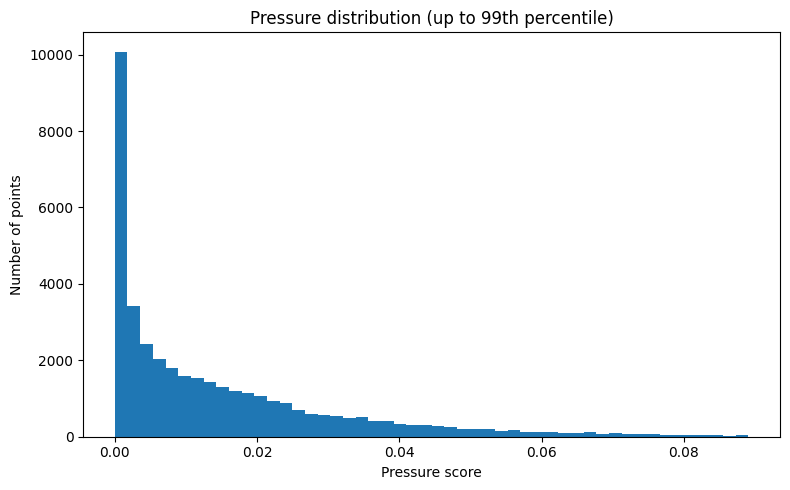

In [18]:
upper_bound = df["pressure_swing"].quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(df.loc[df["pressure_swing"] <= upper_bound, "pressure_swing"], bins=50)
plt.xlabel("Pressure score")
plt.ylabel("Number of points")
plt.title("Pressure distribution (up to 99th percentile)")
plt.tight_layout()
plt.show()

Candidate threshold

In [19]:
thresholds = {
    "top_10_pct": df["pressure_swing"].quantile(0.90),
    "top_5_pct": df["pressure_swing"].quantile(0.95),
    "top_1_pct": df["pressure_swing"].quantile(0.99),
}

thresholds

{'top_10_pct': np.float64(0.04041689441228456),
 'top_5_pct': np.float64(0.05492504181595303),
 'top_1_pct': np.float64(0.08917806103285339)}